# 1. Environment Setup and Tensor Basics

This section verifies the PyTorch environment, selects the available computing device, and demonstrates basic tensor operations.

**Objectives**
- Import the libraries used in the lab.
- Check the installed PyTorch and CUDA versions.
- Select CPU or GPU.
- Verify basic tensor operations.


In [2]:
from pathlib import Path
import copy
import csv
import hashlib
import random
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim


# ------------------------------------------------------------
# 1. Tìm thư mục gốc repository
# ------------------------------------------------------------
def find_repo_root(start_path: Path) -> Path:
    start_path = start_path.resolve()

    for current_path in [start_path, *start_path.parents]:
        if (current_path / "Practice_1").is_dir():
            return current_path

    raise FileNotFoundError(
        "Không tìm thấy thư mục gốc chứa Practice_1."
    )


REPO_ROOT = find_repo_root(Path.cwd())

PRACTICE_DIR = REPO_ROOT / "Practice_1"
SRC_DIR = PRACTICE_DIR / "src"

DATA_DIR = REPO_ROOT / "data"
FIGURE_DIR = PRACTICE_DIR / "figures"
MODEL_DIR = PRACTICE_DIR / "models"
EXPERIMENT_DIR = PRACTICE_DIR / "experiments"


# ------------------------------------------------------------
# 2. Tạo các thư mục đầu ra
# ------------------------------------------------------------
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
EXPERIMENT_DIR.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# 3. Thêm Practice_1/src vào Python path
# ------------------------------------------------------------
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))


# ------------------------------------------------------------
# 4. Import module dùng chung của TV2 và TV3
# ------------------------------------------------------------
from data import create_dataloaders
from model import NeuralNetwork


try:
    from data import CLASS_NAMES
except ImportError:
    CLASS_NAMES = [
        "T-shirt/top",
        "Trouser",
        "Pullover",
        "Dress",
        "Coat",
        "Sandal",
        "Shirt",
        "Sneaker",
        "Bag",
        "Ankle boot",
    ]


# ------------------------------------------------------------
# 5. Cấu hình chung
# ------------------------------------------------------------
SEED = 42

BASELINE_BATCH_SIZE = 64
BASELINE_LEARNING_RATE = 0.001
BASELINE_EPOCHS = 10


def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(SEED)


# ------------------------------------------------------------
# 6. Chọn thiết bị
# ------------------------------------------------------------
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)


# ------------------------------------------------------------
# 7. Kiểm tra
# ------------------------------------------------------------
print("COMMON SETUP COMPLETED")
print("=" * 60)
print("Repository root :", REPO_ROOT)
print("Practice folder :", PRACTICE_DIR)
print("Source folder   :", SRC_DIR)
print("Data folder     :", DATA_DIR)
print("Figure folder   :", FIGURE_DIR)
print("Model folder    :", MODEL_DIR)
print("Device          :", device)
print("PyTorch version :", torch.__version__)
print("Random seed     :", SEED)

COMMON SETUP COMPLETED
Repository root : D:\GTVT-UTH\HK_He_2026\DEEP_LEARNING\UTH-Deep-Learning-nhom2
Practice folder : D:\GTVT-UTH\HK_He_2026\DEEP_LEARNING\UTH-Deep-Learning-nhom2\Practice_1
Source folder   : D:\GTVT-UTH\HK_He_2026\DEEP_LEARNING\UTH-Deep-Learning-nhom2\Practice_1\src
Data folder     : D:\GTVT-UTH\HK_He_2026\DEEP_LEARNING\UTH-Deep-Learning-nhom2\data
Figure folder   : D:\GTVT-UTH\HK_He_2026\DEEP_LEARNING\UTH-Deep-Learning-nhom2\Practice_1\figures
Model folder    : D:\GTVT-UTH\HK_He_2026\DEEP_LEARNING\UTH-Deep-Learning-nhom2\Practice_1\models
Device          : cpu
PyTorch version : 2.13.0+cpu
Random seed     : 42


## Tensor demonstration

A tensor is the main data structure in PyTorch. It can represent vectors, matrices, images, and other numerical data. The following example verifies shape, data type, arithmetic operations, matrix multiplication, and device transfer.


In [3]:
x = torch.tensor([
    [1.0, 2.0],
    [3.0, 4.0],
])

y = torch.ones((2, 2))

print("Tensor x:\n", x)
print("\nTensor y:\n", y)
print("\nShape:", x.shape)
print("Data type:", x.dtype)
print("\nAddition:\n", x + y)
print("\nElement-wise multiplication:\n", x * y)
print("\nMatrix multiplication:\n", x @ y)

x = x.to(device)
print("\nTensor device:", x.device)


Tensor x:
 tensor([[1., 2.],
        [3., 4.]])

Tensor y:
 tensor([[1., 1.],
        [1., 1.]])

Shape: torch.Size([2, 2])
Data type: torch.float32

Addition:
 tensor([[2., 3.],
        [4., 5.]])

Element-wise multiplication:
 tensor([[1., 2.],
        [3., 4.]])

Matrix multiplication:
 tensor([[3., 3.],
        [7., 7.]])

Tensor device: cpu


## Hàm dùng chung cho Tv 3 4 5 Không cần mỗi phần gọi lại create_dataloaders() với cùng batch size.

In [4]:
# ============================================================
# LOAD BASELINE DATA
# ============================================================

(
    train_dataset,
    test_dataset,
    train_loader,
    test_loader,
) = create_dataloaders(
    data_dir=DATA_DIR,
    batch_size=BASELINE_BATCH_SIZE,
)

images, labels = next(iter(train_loader))

print("Training samples :", len(train_dataset))
print("Test samples     :", len(test_dataset))
print("Training batches :", len(train_loader))
print("Test batches     :", len(test_loader))
print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

Training samples : 60000
Test samples     : 10000
Training batches : 938
Test batches     : 157
Image batch shape: torch.Size([64, 1, 28, 28])
Label batch shape: torch.Size([64])


# 02 FashionMNIST Dataset

In this section, the FashionMNIST dataset is loaded and prepared
for the image classification task.

FashionMNIST contains grayscale images of clothing items belonging
to 10 different classes. The dataset is divided into a training set
and a test set.

The dataset is loaded directly using
`torchvision.datasets.FashionMNIST`.


## Data Transformation

Before the images are used by the neural network, they are converted
to PyTorch tensors using `transforms.ToTensor()`.

This transformation converts the image data into a tensor representation
that can be processed by PyTorch.


In [5]:
from pathlib import Path

import torch
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import sys

print("Python executable:")
print(sys.executable)
import torch
import torchvision

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("PyTorch imported successfully!")
current_dir = Path.cwd()

if (current_dir / "Practice_1").exists():
    REPO_ROOT = current_dir
elif current_dir.name == "notebooks":
    REPO_ROOT = current_dir.parents[1]
else:
    REPO_ROOT = current_dir

DATA_DIR = REPO_ROOT / "data"
FIGURE_DIR = REPO_ROOT / "Practice_1" / "figures"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Repository root:", REPO_ROOT)
print("Dataset directory:", DATA_DIR)
print("Figure directory:", FIGURE_DIR)

Python executable:
d:\GTVT-UTH\HK_He_2026\DEEP_LEARNING\UTH-Deep-Learning-nhom2\.venv\Scripts\python.exe
PyTorch version: 2.13.0+cpu
Torchvision version: 0.28.0+cpu
PyTorch imported successfully!
Repository root: d:\GTVT-UTH\HK_He_2026\DEEP_LEARNING\UTH-Deep-Learning-nhom2
Dataset directory: d:\GTVT-UTH\HK_He_2026\DEEP_LEARNING\UTH-Deep-Learning-nhom2\data
Figure directory: d:\GTVT-UTH\HK_He_2026\DEEP_LEARNING\UTH-Deep-Learning-nhom2\Practice_1\figures


In [6]:
transform = transforms.Compose([
    transforms.ToTensor()
])

print(transform)
# Use the official FashionMNIST GitHub repository as a download mirror
datasets.FashionMNIST.mirrors = [
    "https://raw.githubusercontent.com/zalandoresearch/fashion-mnist/master/data/fashion/"
]

print("FashionMNIST mirror updated.")
train_dataset = datasets.FashionMNIST(
    root=str(DATA_DIR),
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root=str(DATA_DIR),
    train=False,
    download=True,
    transform=transform
)

print("FashionMNIST loaded successfully!")
print("Number of training samples:", len(train_dataset))
print("Number of test samples:", len(test_dataset))

image, label = train_dataset[0]

print("\nFirst sample")
print("Image shape:", image.shape)
print("Label:", label)
print("Data type:", image.dtype)
print("Minimum pixel value:", image.min().item())
print("Maximum pixel value:", image.max().item())

Compose(
    ToTensor()
)
FashionMNIST mirror updated.
FashionMNIST loaded successfully!
Number of training samples: 60000
Number of test samples: 10000

First sample
Image shape: torch.Size([1, 28, 28])
Label: 9
Data type: torch.float32
Minimum pixel value: 0.0
Maximum pixel value: 1.0


### Observation

The dataset was loaded successfully.

Each image is represented as a PyTorch tensor with one grayscale
channel. The image dimensions are suitable for use as input to the
neural network.

After `ToTensor()`, the image values are represented as floating-point
values suitable for PyTorch computations.

In [7]:
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

for index, class_name in enumerate(class_names):
    print(f"{index}: {class_name}")

0: T-shirt/top
1: Trouser
2: Pullover
3: Dress
4: Coat
5: Sandal
6: Shirt
7: Sneaker
8: Bag
9: Ankle boot


## Creating DataLoaders

PyTorch `DataLoader` is used to divide the dataset into mini-batches.

For the training dataset, `shuffle=True` is used so that the samples
are presented in a different order during training.

For the test dataset, `shuffle=False` is used because the test set
is only used for model evaluation.

In [8]:
BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Training DataLoader created.")
print("Test DataLoader created.")
print("Batch size:", BATCH_SIZE)
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

Training DataLoader created.
Test DataLoader created.
Batch size: 64
Image batch shape: torch.Size([64, 1, 28, 28])
Label batch shape: torch.Size([64])


### Batch Inspection

A mini-batch was extracted from the training DataLoader to verify
the data structure.

The image tensor follows the format:

`[batch_size, channels, height, width]`

The label tensor contains the class labels corresponding to the
images in the batch.

Mini-batch training allows the neural network to process a subset
of the training data during each optimization step.

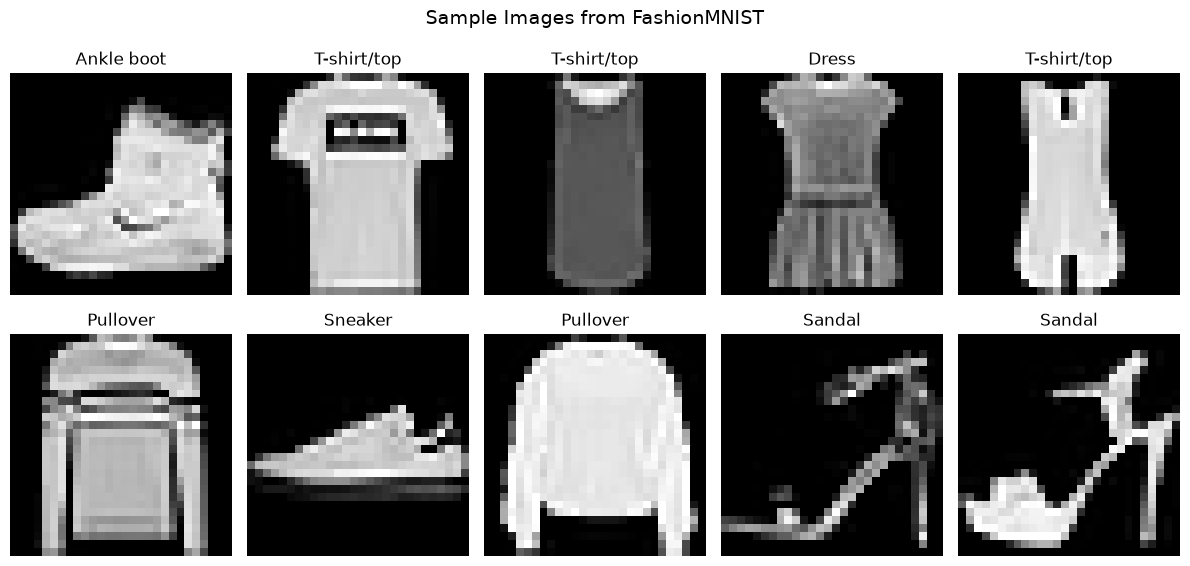

Figure saved to: d:\GTVT-UTH\HK_He_2026\DEEP_LEARNING\UTH-Deep-Learning-nhom2\Practice_1\figures\dataset_samples.png


In [9]:
fig, axes = plt.subplots(2, 5, figsize=(12, 6))

for i, ax in enumerate(axes.flat):
    image, label = train_dataset[i]

    ax.imshow(image.squeeze(), cmap="gray")
    ax.set_title(class_names[label])
    ax.axis("off")

plt.suptitle(
    "Sample Images from FashionMNIST",
    fontsize=14
)

plt.tight_layout()

output_path = FIGURE_DIR / "dataset_samples.png"

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved to:", output_path)

##  DataLoader

PyTorch `DataLoader` is used to divide the dataset into mini-batches
for efficient neural network training.

For the training dataset, `shuffle=True` is used to shuffle the samples
before each training epoch.

For the test dataset, `shuffle=False` is used because the test data
is only used for model evaluation.

In [10]:
BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Train DataLoader created successfully.")
print("Test DataLoader created successfully.")
print("Batch size:", BATCH_SIZE)
print("Number of training batches:", len(train_loader))
print("Number of test batches:", len(test_loader))
images, labels = next(iter(train_loader))

print("Images batch shape:", images.shape)
print("Labels batch shape:", labels.shape)
for i in range(10):
    label_index = labels[i].item()
    print(
        f"Sample {i + 1}: "
        f"Label = {label_index}, "
        f"Class = {class_names[label_index]}"
    )

Train DataLoader created successfully.
Test DataLoader created successfully.
Batch size: 64
Number of training batches: 938
Number of test batches: 157
Images batch shape: torch.Size([64, 1, 28, 28])
Labels batch shape: torch.Size([64])
Sample 1: Label = 4, Class = Coat
Sample 2: Label = 8, Class = Bag
Sample 3: Label = 1, Class = Trouser
Sample 4: Label = 2, Class = Pullover
Sample 5: Label = 4, Class = Coat
Sample 6: Label = 8, Class = Bag
Sample 7: Label = 0, Class = T-shirt/top
Sample 8: Label = 3, Class = Dress
Sample 9: Label = 3, Class = Dress
Sample 10: Label = 9, Class = Ankle boot


#  Mo ta MLP - Kien truc `784 -> 128 -> 64 -> 10`

```
28 x 28 image
      |
   Flatten
      |
     784
      |
    Linear
      |
     128
      |
     ReLU
      |
    Linear
      |
     64
      |
     ReLU
      |
    Linear
      |
  10 outputs (logits)
```

- **Input Layer**: anh dau vao `28 x 28 x 1` (grayscale). `Flatten`
  chuyen anh 2 chieu thanh vector 1 chieu `784` gia tri.
- **Hidden Layer**: 2 lop an fully-connected, `Linear(784, 128)` roi
  `Linear(128, 64)`, hoc cach to hop cac dac trung tu lop truoc.
- **Activation Function**: `ReLU` (`max(0, x)`) sau moi lop an. Neu
  khong co ReLU, nhieu lop `Linear` xep chong nhau ve mat toan hoc chi
  tuong duong 1 phep bien doi tuyen tinh duy nhat, mang se khong hoc
  duoc quan he phi tuyen trong du lieu.
- **Output Layer**: `Linear(64, 10)` tra ve **10 logits**, moi gia tri
  ung voi mot lop trang phuc trong FashionMNIST. Khong dung `Softmax`
  o day (xem giai thich chi tiet o muc 8).


##  Khoi tao model 
##  In model architecture

In [11]:
model = NeuralNetwork().to(device)

print(model)


NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (network): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)


##  Kiem tra input shape

Lay 1 batch anh that tu `train_loader` de kiem tra shape dau vao, va
shape sau khi qua `Flatten`.
# Kiem tra output shape

Dua ca batch qua toan bo model, output phai co shape `[batch, 10]`.



In [12]:
images, labels = next(iter(train_loader))

print("Input shape (truoc Flatten):", images.shape)  # [batch, 1, 28, 28]

flattened = model.flatten(images.to(device))
print("Shape sau Flatten:", flattened.shape)   
images = images.to(device)

with torch.no_grad():
    logits = model(images)

print("Output shape:", logits.shape)  # [batch, 10]
print("Logits cua anh dau tien:\n", logits[0])
       # [batch, 784]


Input shape (truoc Flatten): torch.Size([64, 1, 28, 28])
Shape sau Flatten: torch.Size([64, 784])
Output shape: torch.Size([64, 10])
Logits cua anh dau tien:
 tensor([-0.0056, -0.0410, -0.0655,  0.0220, -0.0719, -0.0563,  0.0309,  0.0464,
         0.0166,  0.1088])


##  Dem trainable parameters


In [13]:
def count_trainable_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


total_params = count_trainable_parameters(model)
print(f"Tong so trainable parameters: {total_params:,}")

for name, param in model.named_parameters():
    print(f"{name:20s} {str(tuple(param.shape)):15s} {param.numel():,} params")
# Minh hoa: argmax tren logits va argmax tren xac suat (sau softmax)
# cho ket qua giong nhau, vi Softmax la phep bien doi don dieu.
probs = torch.softmax(logits, dim=1)

pred_from_logits = torch.argmax(logits, dim=1)
pred_from_probs = torch.argmax(probs, dim=1)

print("Du doan giong nhau:", torch.equal(pred_from_logits, pred_from_probs))
print("Lop du doan (10 anh dau):",
      [class_names[i] for i in pred_from_logits[:10].tolist()])



Tong so trainable parameters: 109,386
network.0.weight     (128, 784)      100,352 params
network.0.bias       (128,)          128 params
network.2.weight     (64, 128)       8,192 params
network.2.bias       (64,)           64 params
network.4.weight     (10, 64)        640 params
network.4.bias       (10,)           10 params
Du doan giong nhau: True
Lop du doan (10 anh dau): ['Ankle boot', 'Ankle boot', 'Ankle boot', 'Ankle boot', 'Ankle boot', 'Ankle boot', 'Shirt', 'Shirt', 'Ankle boot', 'Dress']


## Ham save model

Luu `state_dict` (trong so) cua model ra file `.pth`.
##  Ham load model

Khoi tao lai mot instance `NeuralNetwork` moi va nap trong so da luu
vao. `model.eval()` chuyen model sang che do danh gia.



In [14]:
def save_model(model: nn.Module, path: str = "fashion_mnist.pth") -> None:
    torch.save(model.state_dict(), path)
    print(f"Model da duoc luu vao: {path}")


save_model(model)
def load_model(path: str = "fashion_mnist.pth",
                device: torch.device = device) -> NeuralNetwork:
    loaded_model = NeuralNetwork().to(device)
    loaded_model.load_state_dict(torch.load(path, map_location=device))
    loaded_model.eval()
    return loaded_model


loaded_model = load_model()
print("Model da duoc load thanh cong.")
print(loaded_model)
# Kiem tra: model sau khi load cho ket qua giong het model truoc khi save
with torch.no_grad():
    original_logits = model(images)
    loaded_logits = loaded_model(images)

print("Output giong nhau sau khi load lai:",
      torch.allclose(original_logits, loaded_logits))
images, labels = next(iter(train_loader))
outputs = model(images)

print(outputs.shape)


Model da duoc luu vao: fashion_mnist.pth


Model da duoc load thanh cong.
NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (network): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)
Output giong nhau sau khi load lai: True
torch.Size([64, 10])


# 4. Model Training — FashionMNIST MLP

**Practice 1: FashionMNIST Classification with PyTorch**

sử dụng `data.py` của Thành viên 2 và `model.py`  
## 4.1. Training workflow

Quy trình huấn luyện cho mỗi batch:

`Load batch → Move to device → zero_grad() → Forward → Loss → Backward → optimizer.step()`

- `Forward`: mô hình tạo logits cho 10 lớp FashionMNIST.
- `Loss`: `CrossEntropyLoss` đo sai lệch giữa logits và nhãn thật.
- `Backward`: Autograd tính gradient.
- `optimizer.step()`: Adam cập nhật trọng số mô hình.


In [21]:
test_model = NeuralNetwork()

print(test_model)
import importlib
 
 

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (network): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)


## 4.2. Configuration and reproducibility

Cấu hình baseline của nhóm:

- Batch size: `64`
- Learning rate: `0.001`
- Optimizer: `Adam`
- Number of epochs: `10`
- Loss function: `CrossEntropyLoss`


In [22]:
SEED = 42
BATCH_SIZE = 64
LEARNING_RATE = 0.001
NUM_EPOCHS = 10

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device        :", device)
print("Batch size    :", BATCH_SIZE)
print("Learning rate :", LEARNING_RATE)
print("Epochs        :", NUM_EPOCHS)


Device        : cpu
Batch size    : 64
Learning rate : 0.001
Epochs        : 10


## 4.3. Load FashionMNIST DataLoaders

Dữ liệu được lấy từ hàm dùng chung data.py .  


In [23]:
(
    train_dataset,
    test_dataset,
    train_loader,
    test_loader,
) = create_dataloaders(
    data_dir=DATA_DIR,
    batch_size=BATCH_SIZE,
)

images, labels = next(iter(train_loader))

print("Training samples :", len(train_dataset))
print("Test samples     :", len(test_dataset))
print("Training batches :", len(train_loader))
print("Test batches     :", len(test_loader))
print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

assert images.ndim == 4, "Batch ảnh phải có 4 chiều."
assert images.shape[1:] == (1, 28, 28), "FashionMNIST phải có shape [N, 1, 28, 28]."
assert labels.ndim == 1, "Nhãn phải có shape [N]."
model = NeuralNetwork().to(device)

with torch.no_grad():
    sample_logits = model(images.to(device))

print(model)
print("Input shape :", images.shape)
print("Output shape:", sample_logits.shape)

assert sample_logits.shape == (images.shape[0], 10), (
    "Output của mô hình phải có shape [batch_size, 10]."
)



Training samples : 60000
Test samples     : 10000
Training batches : 938
Test batches     : 157
Image batch shape: torch.Size([64, 1, 28, 28])
Label batch shape: torch.Size([64])
NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (network): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)
Input shape : torch.Size([64, 1, 28, 28])
Output shape: torch.Size([64, 10])


## 4.4. Initialize the MLP model

Mô hình được import từ `Practice_1/src/model.py`. Kiến trúc dùng để huấn luyện và kiến trúc dùng để load checkpoint ở Thành viên 5 phải giống hoàn toàn.


In [24]:
model = NeuralNetwork().to(device)

with torch.no_grad():
    sample_logits = model(images.to(device))

print(model)
print("Input shape :", images.shape)
print("Output shape:", sample_logits.shape)

assert sample_logits.shape == (images.shape[0], 10), (
    "Output của mô hình phải có shape [batch_size, 10]."
)


NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (network): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)
Input shape : torch.Size([64, 1, 28, 28])
Output shape: torch.Size([64, 10])


## 4.5. Loss function and optimizer

- `CrossEntropyLoss` nhận trực tiếp logits và nhãn số nguyên từ `0` đến `9`.
- Không đặt `Softmax` trong lớp cuối của mô hình.
- Adam được dùng với learning rate `0.001` làm cấu hình baseline.
## 4.6. Training function

Hàm dưới đây trả về lịch sử:

- `train_loss`: loss trung bình trên toàn bộ mẫu huấn luyện của mỗi epoch.
- `train_accuracy`: tỷ lệ dự đoán đúng trên tập huấn luyện của mỗi epoch.
- `epoch_time`: thời gian chạy của từng epoch.



In [25]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
)

print("Loss function:", criterion)
print("Optimizer    :", optimizer.__class__.__name__)
def train_model(
    model,
    train_loader,
    criterion,
    optimizer,
    device,
    num_epochs=10,
):
    history = {
        "epoch": [],
        "train_loss": [],
        "train_accuracy": [],
        "epoch_time": [],
    }

    total_start = time.perf_counter()

    for epoch in range(1, num_epochs + 1):
        epoch_start = time.perf_counter()
        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad(set_to_none=True)

            logits = model(images)
            loss = criterion(logits, labels)

            loss.backward()
            optimizer.step()

            batch_size = labels.size(0)
            running_loss += loss.item() * batch_size
            correct += (logits.argmax(dim=1) == labels).sum().item()
            total += batch_size

        epoch_loss = running_loss / total
        epoch_accuracy = 100.0 * correct / total
        epoch_time = time.perf_counter() - epoch_start

        history["epoch"].append(epoch)
        history["train_loss"].append(epoch_loss)
        history["train_accuracy"].append(epoch_accuracy)
        history["epoch_time"].append(epoch_time)

        print(
            f"Epoch [{epoch:02d}/{num_epochs}] "
            f"- Loss: {epoch_loss:.4f} "
            f"- Train Accuracy: {epoch_accuracy:.2f}% "
            f"- Time: {epoch_time:.2f}s"
        )

    total_time = time.perf_counter() - total_start
    print(f"\nTraining completed in {total_time:.2f} seconds.")

    return history, total_time



Loss function: CrossEntropyLoss()
Optimizer    : Adam


# 4.7 Run training and save training 

In [26]:
history, total_training_time = train_model(
    model=model,
    train_loader=train_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    num_epochs=NUM_EPOCHS,
)
HISTORY_PATH = EXPERIMENT_DIR / "tv4_training_history.csv"

with HISTORY_PATH.open("w", newline="", encoding="utf-8") as file:
    writer = csv.writer(file)
    writer.writerow([
        "epoch",
        "train_loss",
        "train_accuracy",
        "epoch_time_seconds",
    ])

    for epoch, loss, accuracy, epoch_time in zip(
        history["epoch"],
        history["train_loss"],
        history["train_accuracy"],
        history["epoch_time"],
    ):
        writer.writerow([
            epoch,
            f"{loss:.6f}",
            f"{accuracy:.4f}",
            f"{epoch_time:.4f}",
        ])

print("Saved training history:", HISTORY_PATH)


Epoch [01/10] - Loss: 0.5595 - Train Accuracy: 80.53% - Time: 16.60s
Epoch [02/10] - Loss: 0.3928 - Train Accuracy: 85.90% - Time: 16.20s
Epoch [03/10] - Loss: 0.3501 - Train Accuracy: 87.20% - Time: 16.90s
Epoch [04/10] - Loss: 0.3243 - Train Accuracy: 88.15% - Time: 16.24s
Epoch [05/10] - Loss: 0.3050 - Train Accuracy: 88.75% - Time: 16.17s
Epoch [06/10] - Loss: 0.2904 - Train Accuracy: 89.16% - Time: 16.37s
Epoch [07/10] - Loss: 0.2761 - Train Accuracy: 89.74% - Time: 16.33s
Epoch [08/10] - Loss: 0.2648 - Train Accuracy: 90.15% - Time: 16.16s
Epoch [09/10] - Loss: 0.2543 - Train Accuracy: 90.55% - Time: 16.15s
Epoch [10/10] - Loss: 0.2467 - Train Accuracy: 90.80% - Time: 16.14s

Training completed in 163.26 seconds.
Saved training history: D:\GTVT-UTH\HK_He_2026\DEEP_LEARNING\UTH-Deep-Learning-nhom2\Practice_1\experiments\tv4_training_history.csv


## 4.9. Plot and save training loss

Biểu đồ loss là một sản phẩm bắt buộc của Practice 1. Đường loss giảm cho thấy quá trình tối ưu đang cải thiện mô hình trên tập huấn luyện.
## 4.10. Plot training accuracy

Training accuracy giúp kiểm tra mô hình có học trên tập train hay không. Đây không phải test accuracy; việc đánh giá trên tập test thuộc phần Thành viên 5.



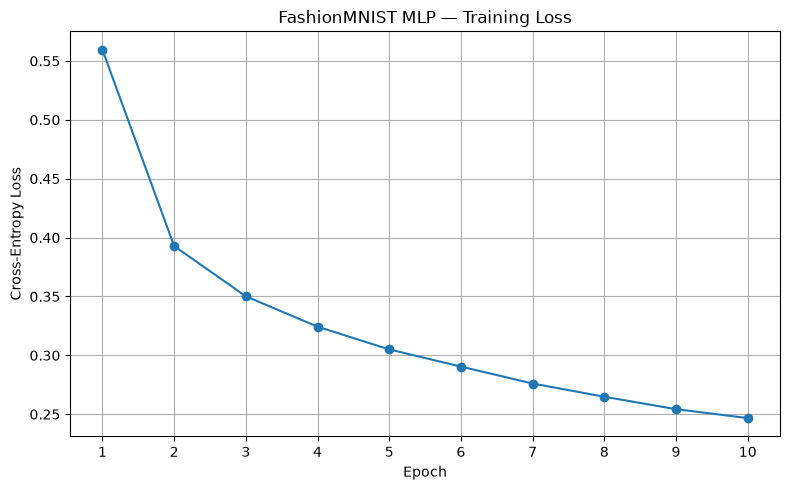

Saved loss graph: d:\GTVT-UTH\HK_He_2026\DEEP_LEARNING\UTH-Deep-Learning-nhom2\Practice_1\figures\training_loss.png


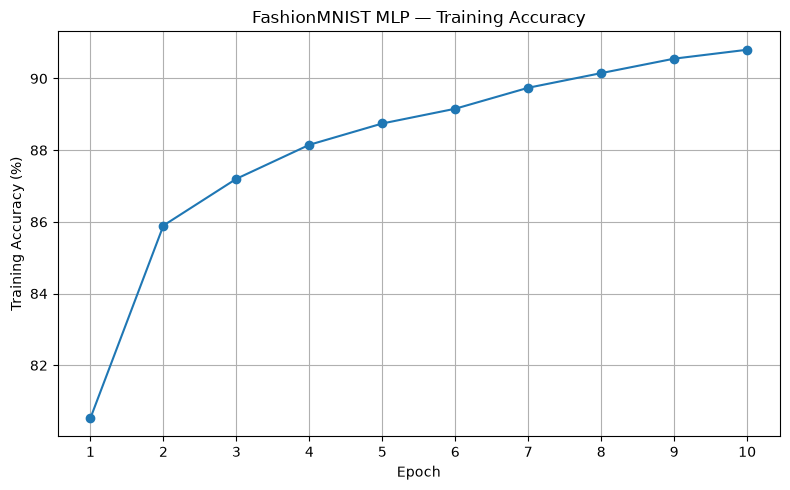

Saved accuracy graph: d:\GTVT-UTH\HK_He_2026\DEEP_LEARNING\UTH-Deep-Learning-nhom2\Practice_1\figures\training_accuracy.png


In [27]:
LOSS_FIGURE_PATH = FIGURE_DIR / "training_loss.png"

plt.figure(figsize=(8, 5))
plt.plot(
    history["epoch"],
    history["train_loss"],
    marker="o",
)
plt.title("FashionMNIST MLP — Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.xticks(history["epoch"])
plt.grid(True)
plt.tight_layout()

plt.savefig(
    LOSS_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
print("Saved loss graph:", LOSS_FIGURE_PATH)
ACCURACY_FIGURE_PATH = FIGURE_DIR / "training_accuracy.png"

plt.figure(figsize=(8, 5))
plt.plot(
    history["epoch"],
    history["train_accuracy"],
    marker="o",
)
plt.title("FashionMNIST MLP — Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Training Accuracy (%)")
plt.xticks(history["epoch"])
plt.grid(True)
plt.tight_layout()

plt.savefig(
    ACCURACY_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
print("Saved accuracy graph:", ACCURACY_FIGURE_PATH)



## 4.11. Save the trained model

Checkpoint được lưu **sau khi huấn luyện**. Thành viên 5 dùng đúng file này để tính test loss, test accuracy và hiển thị dự đoán.


In [28]:
MODEL_PATH = MODEL_DIR / "fashion_mnist_mlp_trained.pth"

torch.save(
    model.state_dict(),
    MODEL_PATH,
)

print("Saved trained model:", MODEL_PATH)
print("Checkpoint size (KB):", MODEL_PATH.stat().st_size / 1024)


Saved trained model: D:\GTVT-UTH\HK_He_2026\DEEP_LEARNING\UTH-Deep-Learning-nhom2\Practice_1\models\fashion_mnist_mlp_trained.pth
Checkpoint size (KB): 430.6064453125


## 4.12. Verify save/load

Cell này kiểm tra checkpoint có thể load lại bằng đúng kiến trúc `NeuralNetwork`. Hai mô hình phải tạo logits giống nhau trên cùng một batch.


In [29]:
reloaded_model = NeuralNetwork().to(device)

state_dict = torch.load(
    MODEL_PATH,
    map_location=device,
    weights_only=True,
)

reloaded_model.load_state_dict(state_dict)
reloaded_model.eval()
model.eval()

verification_images, _ = next(iter(train_loader))
verification_images = verification_images.to(device)

with torch.no_grad():
    original_logits = model(verification_images)
    reloaded_logits = reloaded_model(verification_images)

same_outputs = torch.allclose(
    original_logits,
    reloaded_logits,
    atol=1e-6,
)

print("Checkpoint loaded successfully:", same_outputs)
assert same_outputs, "Output sau khi load checkpoint không khớp model đã lưu."


Checkpoint loaded successfully: True


## 4.13. Training result analysis

Sau khi chạy notebook, cần nhận xét:

1. Loss ở epoch đầu và epoch cuối.
2. Loss có giảm đều hay dao động mạnh.
3. Training accuracy có tăng hay không.
4. Thời gian huấn luyện.
5. Chưa kết luận khả năng tổng quát hóa chỉ từ training loss; cần kết quả test của Thành viên 5.


In [30]:
first_loss = history["train_loss"][0]
final_loss = history["train_loss"][-1]
loss_reduction = first_loss - final_loss

first_accuracy = history["train_accuracy"][0]
final_accuracy = history["train_accuracy"][-1]

print("TRAINING SUMMARY")
print("-" * 50)
print(f"First epoch loss       : {first_loss:.4f}")
print(f"Final epoch loss       : {final_loss:.4f}")
print(f"Loss reduction         : {loss_reduction:.4f}")
print(f"First train accuracy   : {first_accuracy:.2f}%")
print(f"Final train accuracy   : {final_accuracy:.2f}%")
print(f"Total training time    : {total_training_time:.2f}s")
print(f"Saved checkpoint       : {MODEL_PATH.name}")
print(f"Saved loss figure      : {LOSS_FIGURE_PATH.name}")


TRAINING SUMMARY
--------------------------------------------------
First epoch loss       : 0.5595
Final epoch loss       : 0.2467
Loss reduction         : 0.3128
First train accuracy   : 80.53%
Final train accuracy   : 90.80%
Total training time    : 163.26s
Saved checkpoint       : fashion_mnist_mlp_trained.pth
Saved loss figure      : training_loss.png


# 5. Model Evaluation — FashionMNIST MLP

 load tập test, load checkpoint đã train, tính Test Loss/Test Accuracy, phân tích theo lớp, vẽ Confusion Matrix, hiển thị `Actual vs Predicted` và các ảnh dự đoán sai.
 **không train lại mô hình**.


In [31]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn


def find_repo_root(start_path: Path) -> Path:
    start_path = start_path.resolve()
    for current_path in [start_path, *start_path.parents]:
        if (current_path / "Practice_1").is_dir():
            return current_path
    raise FileNotFoundError("Không tìm thấy thư mục gốc chứa Practice_1.")


REPO_ROOT = find_repo_root(Path.cwd())
PRACTICE_DIR = REPO_ROOT / "Practice_1"
SRC_DIR = PRACTICE_DIR / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from data import create_dataloaders
from model import NeuralNetwork

try:
    from data import CLASS_NAMES
except ImportError:
    CLASS_NAMES = [
        "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
        "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot",
    ]

DATA_DIR = REPO_ROOT / "data"
MODEL_DIR = PRACTICE_DIR / "models"
FIGURE_DIR = PRACTICE_DIR / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Repository root:", REPO_ROOT)
print("Device:", device)
print("Classes:", CLASS_NAMES)


Repository root: D:\GTVT-UTH\HK_He_2026\DEEP_LEARNING\UTH-Deep-Learning-nhom2
Device: cpu
Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


## 5.1 kiểm tra model  
## 5.2. Load test dataset
## 5.3. Load model đã huấn luyện




In [32]:
print("DataLoader function:", create_dataloaders)
print("Model class:", NeuralNetwork)

test_model = NeuralNetwork().to(device)
print(test_model)
train_dataset, test_dataset, train_loader, test_loader = create_dataloaders(
    data_dir=DATA_DIR,
    batch_size=64,
)

images, labels = next(iter(test_loader))

print("Test samples:", len(test_dataset))
print("Test batches:", len(test_loader))
print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

assert images.shape[1:] == (1, 28, 28)
MODEL_PATH = MODEL_DIR / "fashion_mnist_mlp_trained.pth"

if not MODEL_PATH.exists():
    raise FileNotFoundError(
        f"Không tìm thấy checkpoint:\n{MODEL_PATH}\n"
        "Hãy chạy 04_training.ipynb hoặc lấy file từ TV4."
    )

model = NeuralNetwork().to(device)
state_dict = torch.load(MODEL_PATH, map_location=device, weights_only=True)
model.load_state_dict(state_dict)
model.eval()

with torch.no_grad():
    sample_logits = model(images.to(device))

print("Loaded checkpoint:", MODEL_PATH)
print("Output shape:", sample_logits.shape)
assert sample_logits.shape[1] == 10



DataLoader function: <function create_dataloaders at 0x0000020739667B00>
Model class: <class 'model.NeuralNetwork'>
NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (network): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)
Test samples: 10000
Test batches: 157
Image batch shape: torch.Size([64, 1, 28, 28])
Label batch shape: torch.Size([64])
Loaded checkpoint: D:\GTVT-UTH\HK_He_2026\DEEP_LEARNING\UTH-Deep-Learning-nhom2\Practice_1\models\fashion_mnist_mlp_trained.pth
Output shape: torch.Size([64, 10])


## 5.4 hàm đánh giá

In [33]:
def evaluate_model(model, test_loader, criterion, device):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    all_labels = []
    all_predictions = []
    all_confidences = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            loss = criterion(logits, labels)

            probabilities = torch.softmax(logits, dim=1)
            confidences, predictions = probabilities.max(dim=1)

            batch_size = labels.size(0)
            total_loss += loss.item() * batch_size
            total_correct += (predictions == labels).sum().item()
            total_samples += batch_size

            all_labels.extend(labels.cpu().tolist())
            all_predictions.extend(predictions.cpu().tolist())
            all_confidences.extend(confidences.cpu().tolist())

    return {
        "test_loss": total_loss / total_samples,
        "test_accuracy": 100.0 * total_correct / total_samples,
        "labels": np.array(all_labels),
        "predictions": np.array(all_predictions),
        "confidences": np.array(all_confidences),
    }


## Chạy đánh giá

In [34]:
criterion = nn.CrossEntropyLoss()

evaluation = evaluate_model(
    model=model,
    test_loader=test_loader,
    criterion=criterion,
    device=device,
)

print("EVALUATION RESULT")
print("-" * 40)
print(f"Test Loss    : {evaluation['test_loss']:.4f}")
print(f"Test Accuracy: {evaluation['test_accuracy']:.2f}%")


EVALUATION RESULT
----------------------------------------
Test Loss    : 0.3278
Test Accuracy: 88.29%


## 5.6 Accuracy theo từng lớp

In [35]:
labels_array = evaluation["labels"]
predictions_array = evaluation["predictions"]

class_correct = np.zeros(len(CLASS_NAMES), dtype=np.int64)
class_total = np.zeros(len(CLASS_NAMES), dtype=np.int64)

for actual, predicted in zip(labels_array, predictions_array):
    class_total[actual] += 1
    if actual == predicted:
        class_correct[actual] += 1

class_accuracy = 100.0 * class_correct / np.maximum(class_total, 1)

print(f"{'Class':<16} {'Correct':>8} {'Total':>8} {'Accuracy':>11}")
print("-" * 48)
for index, class_name in enumerate(CLASS_NAMES):
    print(
        f"{class_name:<16} {class_correct[index]:>8} "
        f"{class_total[index]:>8} {class_accuracy[index]:>10.2f}%"
    )

best_class_index = int(class_accuracy.argmax())
worst_class_index = int(class_accuracy.argmin())


Class             Correct    Total    Accuracy
------------------------------------------------
T-shirt/top           782     1000      78.20%
Trouser               972     1000      97.20%
Pullover              806     1000      80.60%
Dress                 910     1000      91.00%
Coat                  830     1000      83.00%
Sandal                963     1000      96.30%
Shirt                 701     1000      70.10%
Sneaker               968     1000      96.80%
Bag                   956     1000      95.60%
Ankle boot            941     1000      94.10%


## 5.7 Confusion Matrix

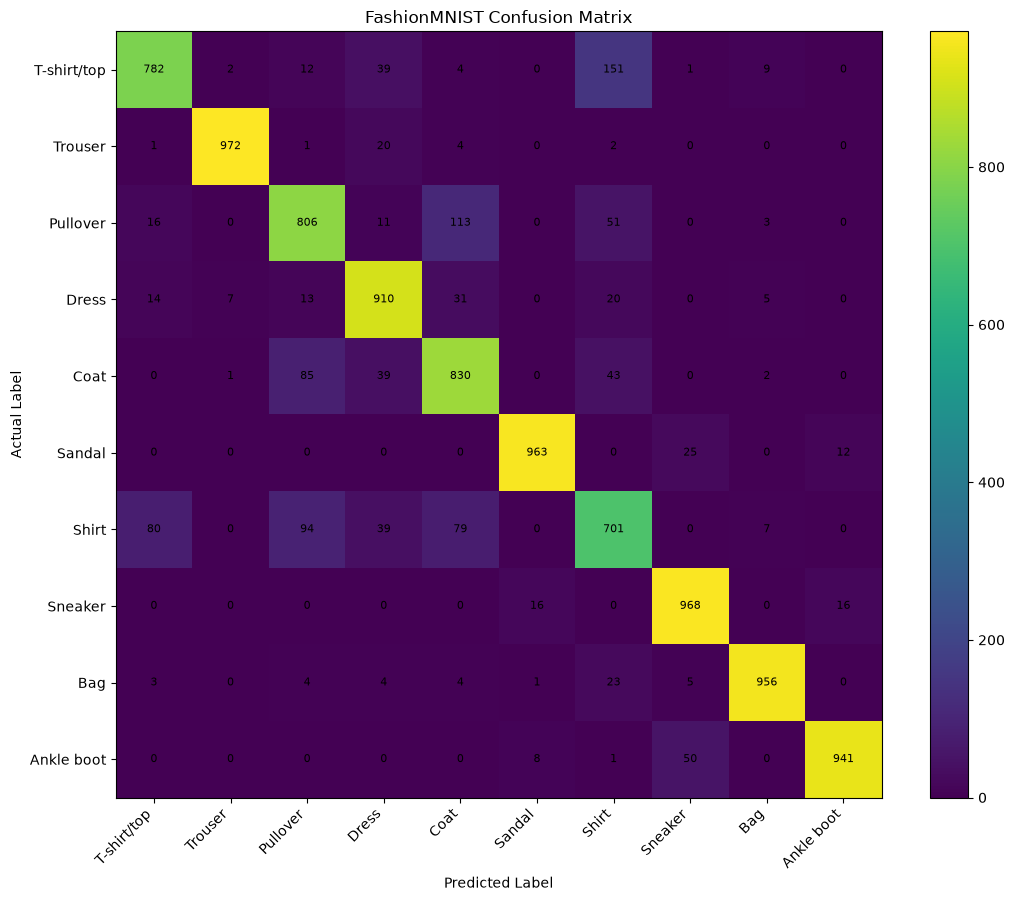

Saved: D:\GTVT-UTH\HK_He_2026\DEEP_LEARNING\UTH-Deep-Learning-nhom2\Practice_1\figures\confusion_matrix.png


In [36]:
def build_confusion_matrix(labels, predictions, num_classes=10):
    matrix = np.zeros((num_classes, num_classes), dtype=np.int64)
    for actual, predicted in zip(labels, predictions):
        matrix[actual, predicted] += 1
    return matrix


confusion_matrix = build_confusion_matrix(
    labels_array,
    predictions_array,
    num_classes=len(CLASS_NAMES),
)

CONFUSION_MATRIX_PATH = FIGURE_DIR / "confusion_matrix.png"

fig, ax = plt.subplots(figsize=(11, 9))
image = ax.imshow(confusion_matrix)
ax.set_title("FashionMNIST Confusion Matrix")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("Actual Label")
ax.set_xticks(range(len(CLASS_NAMES)))
ax.set_yticks(range(len(CLASS_NAMES)))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
ax.set_yticklabels(CLASS_NAMES)

for row in range(confusion_matrix.shape[0]):
    for column in range(confusion_matrix.shape[1]):
        ax.text(column, row, str(confusion_matrix[row, column]),
                ha="center", va="center", fontsize=8)

fig.colorbar(image, ax=ax)
fig.tight_layout()
fig.savefig(CONFUSION_MATRIX_PATH, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", CONFUSION_MATRIX_PATH)


## 5.8 ACtual vs Predicted

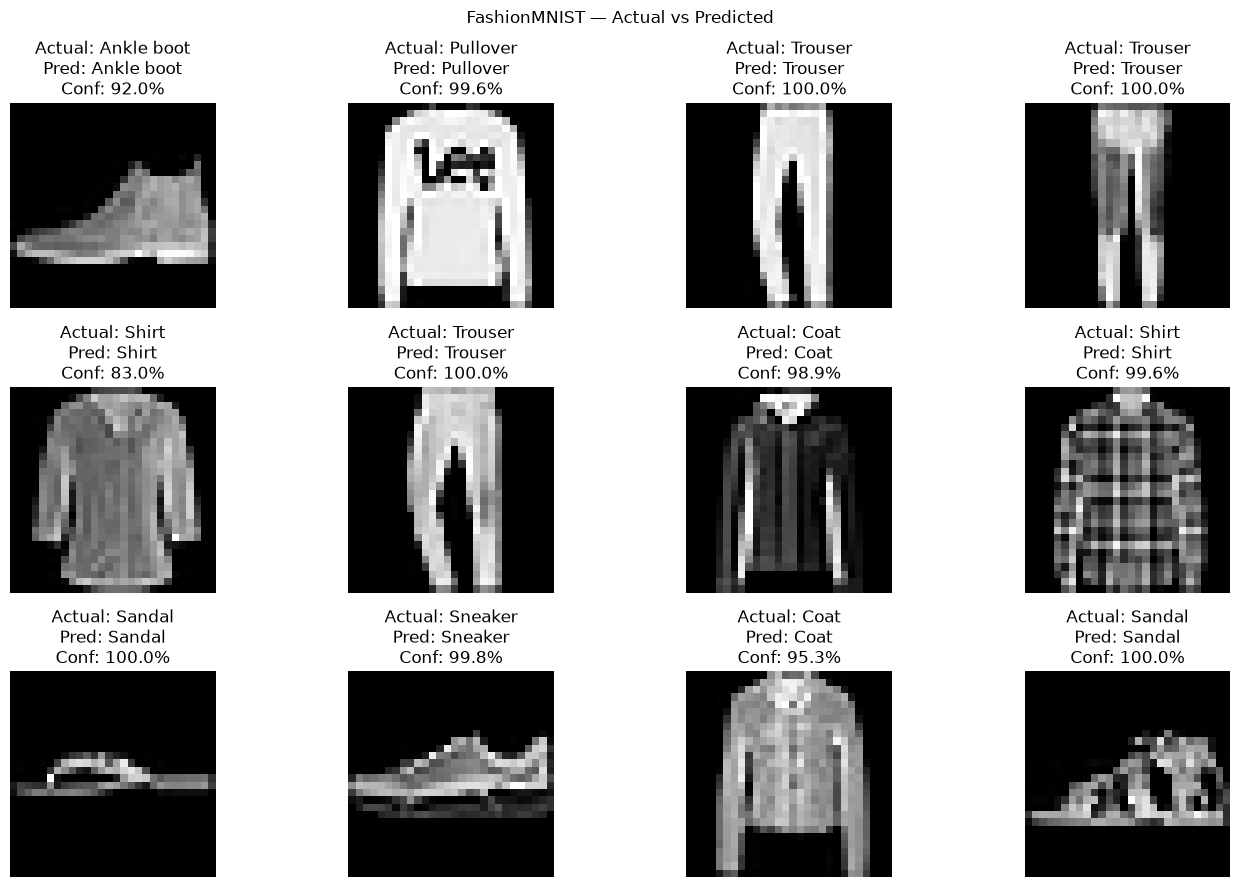

Saved: D:\GTVT-UTH\HK_He_2026\DEEP_LEARNING\UTH-Deep-Learning-nhom2\Practice_1\figures\predicted_vs_actual.png


In [37]:
def show_predictions(model, test_loader, class_names, device, figure_path, num_images=12):
    model.eval()
    images, labels = next(iter(test_loader))

    with torch.no_grad():
        logits = model(images.to(device))
        probabilities = torch.softmax(logits, dim=1)
        confidences, predictions = probabilities.max(dim=1)

    predictions = predictions.cpu()
    confidences = confidences.cpu()
    num_images = min(num_images, len(images))

    fig = plt.figure(figsize=(14, 9))
    for index in range(num_images):
        ax = fig.add_subplot(3, 4, index + 1)
        ax.imshow(images[index].squeeze(), cmap="gray")

        actual = class_names[labels[index].item()]
        predicted = class_names[predictions[index].item()]
        confidence = 100.0 * confidences[index].item()

        ax.set_title(
            f"Actual: {actual}\nPred: {predicted}\nConf: {confidence:.1f}%"
        )
        ax.axis("off")

    fig.suptitle("FashionMNIST — Actual vs Predicted")
    fig.tight_layout()
    fig.savefig(figure_path, dpi=300, bbox_inches="tight")
    plt.show()


PREDICTION_PATH = FIGURE_DIR / "predicted_vs_actual.png"
show_predictions(model, test_loader, CLASS_NAMES, device, PREDICTION_PATH)
print("Saved:", PREDICTION_PATH)


## 5.9 Các ảnh dự đoán sai

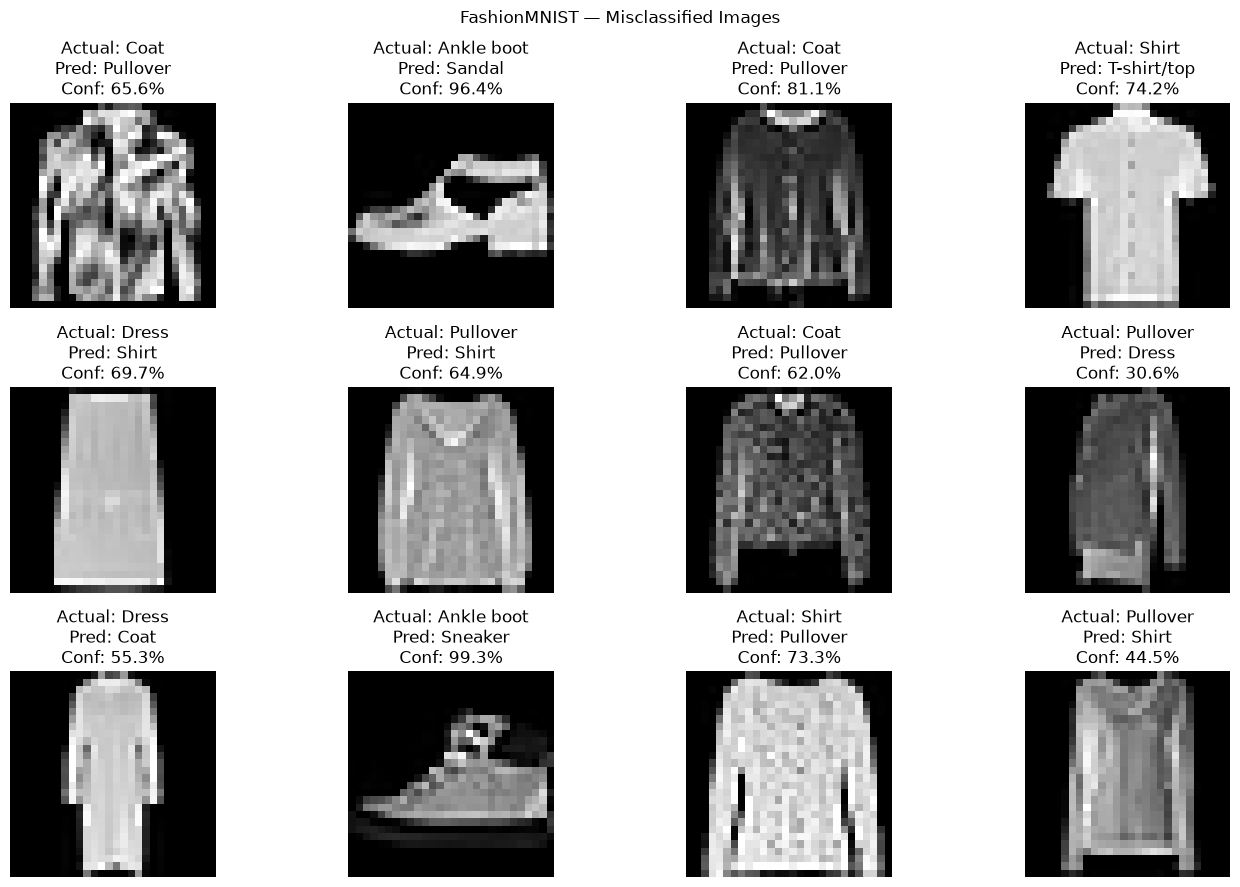

Saved: D:\GTVT-UTH\HK_He_2026\DEEP_LEARNING\UTH-Deep-Learning-nhom2\Practice_1\figures\misclassified_images.png


In [38]:
def show_misclassified_images(model, test_loader, class_names, device, figure_path, num_images=12):
    model.eval()
    wrong_images, wrong_labels, wrong_predictions, wrong_confidences = [], [], [], []

    with torch.no_grad():
        for images, labels in test_loader:
            logits = model(images.to(device))
            probabilities = torch.softmax(logits, dim=1)
            confidences, predictions = probabilities.max(dim=1)

            predictions = predictions.cpu()
            confidences = confidences.cpu()
            wrong_mask = predictions != labels

            for image, actual, predicted, confidence in zip(
                images[wrong_mask], labels[wrong_mask],
                predictions[wrong_mask], confidences[wrong_mask],
            ):
                wrong_images.append(image)
                wrong_labels.append(actual.item())
                wrong_predictions.append(predicted.item())
                wrong_confidences.append(confidence.item())
                if len(wrong_images) >= num_images:
                    break
            if len(wrong_images) >= num_images:
                break

    fig = plt.figure(figsize=(14, 9))
    for index, image in enumerate(wrong_images):
        ax = fig.add_subplot(3, 4, index + 1)
        ax.imshow(image.squeeze(), cmap="gray")
        actual = class_names[wrong_labels[index]]
        predicted = class_names[wrong_predictions[index]]
        confidence = 100.0 * wrong_confidences[index]
        ax.set_title(
            f"Actual: {actual}\nPred: {predicted}\nConf: {confidence:.1f}%"
        )
        ax.axis("off")

    fig.suptitle("FashionMNIST — Misclassified Images")
    fig.tight_layout()
    fig.savefig(figure_path, dpi=300, bbox_inches="tight")
    plt.show()


MISCLASSIFIED_PATH = FIGURE_DIR / "misclassified_images.png"
show_misclassified_images(
    model, test_loader, CLASS_NAMES, device, MISCLASSIFIED_PATH
)
print("Saved:", MISCLASSIFIED_PATH)


## 5.10 Các cặp lớp bị nhầm lẫn nhiều nhất

In [39]:
confusion_pairs = []
for actual_index in range(len(CLASS_NAMES)):
    for predicted_index in range(len(CLASS_NAMES)):
        if actual_index == predicted_index:
            continue
        confusion_pairs.append((
            int(confusion_matrix[actual_index, predicted_index]),
            CLASS_NAMES[actual_index],
            CLASS_NAMES[predicted_index],
        ))

confusion_pairs.sort(reverse=True)

print("Top 5 most common confusions")
print("-" * 60)
for rank, (count, actual_name, predicted_name) in enumerate(confusion_pairs[:5], 1):
    print(
        f"{rank}. Actual: {actual_name:<14} "
        f"→ Predicted: {predicted_name:<14} ({count} images)"
    )


Top 5 most common confusions
------------------------------------------------------------
1. Actual: T-shirt/top    → Predicted: Shirt          (151 images)
2. Actual: Pullover       → Predicted: Coat           (113 images)
3. Actual: Shirt          → Predicted: Pullover       (94 images)
4. Actual: Coat           → Predicted: Pullover       (85 images)
5. Actual: Shirt          → Predicted: T-shirt/top    (80 images)


## 5.11 Tổng kết

In [40]:
print("FINAL EVALUATION SUMMARY REPORT")
print(f"Test Loss     : {evaluation['test_loss']:.4f}")
print(f"Test Accuracy : {evaluation['test_accuracy']:.2f}%")
print(
    f"Best class    : {CLASS_NAMES[best_class_index]} "
    f"({class_accuracy[best_class_index]:.2f}%)"
)
print(
    f"Worst class   : {CLASS_NAMES[worst_class_index]} "
    f"({class_accuracy[worst_class_index]:.2f}%)"
)
print("Checkpoint    :", MODEL_PATH.name)
print("Confusion file:", CONFUSION_MATRIX_PATH.name)
print("Prediction file:", PREDICTION_PATH.name)
print("Error file    :", MISCLASSIFIED_PATH.name)


FINAL EVALUATION SUMMARY REPORT
Test Loss     : 0.3278
Test Accuracy : 88.29%
Best class    : Trouser (97.20%)
Worst class   : Shirt (70.10%)
Checkpoint    : fashion_mnist_mlp_trained.pth
Confusion file: confusion_matrix.png
Prediction file: predicted_vs_actual.png
Error file    : misclassified_images.png


# 6. Hyperparameter Experiments — FashionMNIST MLP

 Xây dựng baseline.
 Thử learning rate, batch size, optimizer và hidden layers.
 Huấn luyện lại từng cấu hình từ đầu.
 Đánh giá trên cùng tập test.
 So sánh Test Loss, Test Accuracy và thời gian.
 Chọn cấu hình tốt nhất.

 


In [41]:
from pathlib import Path
import copy
import csv
import random
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from data import create_dataloaders
from model import NeuralNetwork


def find_repo_root(start):
    start = Path(start).resolve()

    for current in [start, *start.parents]:
        if (current / "Practice_1").is_dir():
            return current

    raise FileNotFoundError(
        "Không tìm thấy thư mục gốc chứa Practice_1."
    )


REPO_ROOT = find_repo_root(Path.cwd())
PRACTICE_DIR = REPO_ROOT / "Practice_1"
SRC_DIR = PRACTICE_DIR / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from data import create_dataloaders

DATA_DIR = REPO_ROOT / "data"
FIGURE_DIR = PRACTICE_DIR / "figures"
MODEL_DIR = PRACTICE_DIR / "models"
EXPERIMENT_DIR = PRACTICE_DIR / "experiments"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
EXPERIMENT_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Repository root:", REPO_ROOT)
print("Device:", device)


Repository root: D:\GTVT-UTH\HK_He_2026\DEEP_LEARNING\UTH-Deep-Learning-nhom2
Device: cpu


## 6.1. Reproducibility and common settings

Tất cả thí nghiệm dùng cùng seed và cùng số epoch để so sánh công bằng.


In [42]:
SEED = 42
EPOCHS = 10


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(SEED)

print("Seed:", SEED)
print("Epochs per experiment:", EPOCHS)


Seed: 42
Epochs per experiment: 10


## 6.2. Configurable MLP

Baseline tương đương kiến trúc của TV3:

`784 → 128 → 64 → 10`


In [43]:
class ConfigurableMLP(nn.Module):
    def __init__(self, hidden_sizes=(128, 64)):
        super().__init__()

        layers = [nn.Flatten()]
        input_size = 28 * 28

        for hidden_size in hidden_sizes:
            layers.extend([
                nn.Linear(input_size, hidden_size),
                nn.ReLU(),
            ])
            input_size = hidden_size

        layers.append(nn.Linear(input_size, 10))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


dummy_model = ConfigurableMLP((128, 64))
dummy_input = torch.randn(64, 1, 28, 28)

with torch.no_grad():
    dummy_output = dummy_model(dummy_input)

print(dummy_model)
print("Output shape:", dummy_output.shape)
assert dummy_output.shape == (64, 10)


ConfigurableMLP(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=10, bias=True)
  )
)
Output shape: torch.Size([64, 10])


## 6.3. Experiment configurations

| Experiment | Batch | Learning rate | Optimizer | Hidden layers |
|---|---:|---:|---|---|
| Baseline | 64 | 0.001 | Adam | 128–64 |
| Lower LR | 64 | 0.0005 | Adam | 128–64 |
| Higher LR | 64 | 0.005 | Adam | 128–64 |
| Smaller Batch | 32 | 0.001 | Adam | 128–64 |
| SGD | 64 | 0.01 | SGD + momentum | 128–64 |
| Wider Network | 64 | 0.001 | Adam | 256–128 |


In [44]:
EXPERIMENTS = [
    {
        "name": "Baseline",
        "batch_size": 64,
        "learning_rate": 0.001,
        "optimizer": "Adam",
        "hidden_sizes": (128, 64),
    },
    {
        "name": "Lower LR",
        "batch_size": 64,
        "learning_rate": 0.0005,
        "optimizer": "Adam",
        "hidden_sizes": (128, 64),
    },
    {
        "name": "Higher LR",
        "batch_size": 64,
        "learning_rate": 0.005,
        "optimizer": "Adam",
        "hidden_sizes": (128, 64),
    },
    {
        "name": "Smaller Batch",
        "batch_size": 32,
        "learning_rate": 0.001,
        "optimizer": "Adam",
        "hidden_sizes": (128, 64),
    },
    {
        "name": "SGD",
        "batch_size": 64,
        "learning_rate": 0.01,
        "optimizer": "SGD",
        "momentum": 0.9,
        "hidden_sizes": (128, 64),
    },
    {
        "name": "Wider Network",
        "batch_size": 64,
        "learning_rate": 0.001,
        "optimizer": "Adam",
        "hidden_sizes": (256, 128),
    },
]

for experiment in EXPERIMENTS:
    print(experiment)


{'name': 'Baseline', 'batch_size': 64, 'learning_rate': 0.001, 'optimizer': 'Adam', 'hidden_sizes': (128, 64)}
{'name': 'Lower LR', 'batch_size': 64, 'learning_rate': 0.0005, 'optimizer': 'Adam', 'hidden_sizes': (128, 64)}
{'name': 'Higher LR', 'batch_size': 64, 'learning_rate': 0.005, 'optimizer': 'Adam', 'hidden_sizes': (128, 64)}
{'name': 'Smaller Batch', 'batch_size': 32, 'learning_rate': 0.001, 'optimizer': 'Adam', 'hidden_sizes': (128, 64)}
{'name': 'SGD', 'batch_size': 64, 'learning_rate': 0.01, 'optimizer': 'SGD', 'momentum': 0.9, 'hidden_sizes': (128, 64)}
{'name': 'Wider Network', 'batch_size': 64, 'learning_rate': 0.001, 'optimizer': 'Adam', 'hidden_sizes': (256, 128)}


## 6.4. Training and evaluation functions


In [45]:
def build_optimizer(model, config):
    if config["optimizer"] == "Adam":
        return optim.Adam(
            model.parameters(),
            lr=config["learning_rate"],
        )

    if config["optimizer"] == "SGD":
        return optim.SGD(
            model.parameters(),
            lr=config["learning_rate"],
            momentum=config.get("momentum", 0.0),
        )

    raise ValueError("Unsupported optimizer")


def train_model(
    model,
    train_loader,
    optimizer,
    device,
    epochs,
):
    criterion = nn.CrossEntropyLoss()
    loss_history = []
    accuracy_history = []

    start_time = time.perf_counter()

    for epoch in range(1, epochs + 1):
        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad(set_to_none=True)

            logits = model(images)
            loss = criterion(logits, labels)

            loss.backward()
            optimizer.step()

            batch_size = labels.size(0)

            running_loss += loss.item() * batch_size
            correct += (
                logits.argmax(dim=1) == labels
            ).sum().item()
            total += batch_size

        epoch_loss = running_loss / total
        epoch_accuracy = 100.0 * correct / total

        loss_history.append(epoch_loss)
        accuracy_history.append(epoch_accuracy)

        print(
            f"Epoch [{epoch}/{epochs}] "
            f"- Loss: {epoch_loss:.4f} "
            f"- Train Accuracy: {epoch_accuracy:.2f}%"
        )

    training_time = time.perf_counter() - start_time

    return loss_history, accuracy_history, training_time


def evaluate_model(model, test_loader, device):
    model.eval()

    criterion = nn.CrossEntropyLoss(reduction="sum")

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    with torch.inference_mode():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)

            total_loss += criterion(
                logits,
                labels,
            ).item()

            predictions = logits.argmax(dim=1)

            total_correct += (
                predictions == labels
            ).sum().item()

            total_samples += labels.size(0)

    return (
        total_loss / total_samples,
        100.0 * total_correct / total_samples,
    )


## 6.5. Run all experiments

Mỗi cấu hình được khởi tạo và huấn luyện lại từ đầu. Trên CPU, phần này có thể mất vài phút.


In [46]:
results = []
histories = {}

best_accuracy = -1.0
best_state_dict = None
best_config = None

for index, config in enumerate(EXPERIMENTS, start=1):
    print("\n" + "=" * 70)
    print(
        f"Experiment {index}/{len(EXPERIMENTS)}: "
        f"{config['name']}"
    )
    print("=" * 70)

    set_seed(SEED)

    (
        train_dataset,
        test_dataset,
        train_loader,
        test_loader,
    ) = create_dataloaders(
        data_dir=DATA_DIR,
        batch_size=config["batch_size"],
    )

    model = ConfigurableMLP(
        hidden_sizes=config["hidden_sizes"]
    ).to(device)

    optimizer = build_optimizer(model, config)

    (
        loss_history,
        accuracy_history,
        training_time,
    ) = train_model(
        model=model,
        train_loader=train_loader,
        optimizer=optimizer,
        device=device,
        epochs=EPOCHS,
    )

    test_loss, test_accuracy = evaluate_model(
        model=model,
        test_loader=test_loader,
        device=device,
    )

    result = {
        "experiment": config["name"],
        "batch_size": config["batch_size"],
        "learning_rate": config["learning_rate"],
        "optimizer": config["optimizer"],
        "hidden_sizes": "-".join(
            map(str, config["hidden_sizes"])
        ),
        "epochs": EPOCHS,
        "final_train_loss": loss_history[-1],
        "final_train_accuracy":
            accuracy_history[-1],
        "test_loss": test_loss,
        "test_accuracy": test_accuracy,
        "training_time_seconds": training_time,
    }

    results.append(result)

    histories[config["name"]] = loss_history

    print(f"Test Loss    : {test_loss:.4f}")
    print(f"Test Accuracy: {test_accuracy:.2f}%")
    print(f"Training Time: {training_time:.2f}s")

    if test_accuracy > best_accuracy:
        best_accuracy = test_accuracy
        best_state_dict = copy.deepcopy(
            model.state_dict()
        )
        best_config = copy.deepcopy(config)



Experiment 1/6: Baseline
Epoch [1/10] - Loss: 0.5616 - Train Accuracy: 80.07%
Epoch [2/10] - Loss: 0.3890 - Train Accuracy: 86.07%
Epoch [3/10] - Loss: 0.3487 - Train Accuracy: 87.39%
Epoch [4/10] - Loss: 0.3225 - Train Accuracy: 88.21%
Epoch [5/10] - Loss: 0.3087 - Train Accuracy: 88.55%
Epoch [6/10] - Loss: 0.2889 - Train Accuracy: 89.44%
Epoch [7/10] - Loss: 0.2781 - Train Accuracy: 89.63%
Epoch [8/10] - Loss: 0.2662 - Train Accuracy: 90.18%
Epoch [9/10] - Loss: 0.2586 - Train Accuracy: 90.32%
Epoch [10/10] - Loss: 0.2458 - Train Accuracy: 90.84%
Test Loss    : 0.3380
Test Accuracy: 88.09%
Training Time: 76.32s

Experiment 2/6: Lower LR
Epoch [1/10] - Loss: 0.6181 - Train Accuracy: 78.61%
Epoch [2/10] - Loss: 0.4178 - Train Accuracy: 85.38%
Epoch [3/10] - Loss: 0.3797 - Train Accuracy: 86.51%
Epoch [4/10] - Loss: 0.3496 - Train Accuracy: 87.56%
Epoch [5/10] - Loss: 0.3318 - Train Accuracy: 88.00%
Epoch [6/10] - Loss: 0.3127 - Train Accuracy: 88.77%
Epoch [7/10] - Loss: 0.3009 - Tra

## 6.6. Comparison table


In [47]:
header = (
    f"{'Experiment':<18}"
    f"{'Batch':>7}"
    f"{'LR':>10}"
    f"{'Optimizer':>11}"
    f"{'Hidden':>12}"
    f"{'Test Loss':>12}"
    f"{'Test Acc':>11}"
    f"{'Time(s)':>10}"
)

print(header)
print("-" * len(header))

for result in results:
    print(
        f"{result['experiment']:<18}"
        f"{result['batch_size']:>7}"
        f"{result['learning_rate']:>10.4f}"
        f"{result['optimizer']:>11}"
        f"{result['hidden_sizes']:>12}"
        f"{result['test_loss']:>12.4f}"
        f"{result['test_accuracy']:>10.2f}%"
        f"{result['training_time_seconds']:>10.2f}"
    )


Experiment          Batch        LR  Optimizer      Hidden   Test Loss   Test Acc   Time(s)
-------------------------------------------------------------------------------------------
Baseline               64    0.0010       Adam      128-64      0.3380     88.09%     76.32
Lower LR               64    0.0005       Adam      128-64      0.3436     87.80%     75.28
Higher LR              64    0.0050       Adam      128-64      0.3719     86.85%     70.70
Smaller Batch          32    0.0010       Adam      128-64      0.3371     88.18%     90.77
SGD                    64    0.0100        SGD      128-64      0.3359     87.90%     70.96
Wider Network          64    0.0010       Adam     256-128      0.3266     88.60%     91.61


## 6.7 Save results to CSV 

In [48]:
RESULTS_PATH = (
    EXPERIMENT_DIR
    / "hyperparameter_results.csv"
)

with RESULTS_PATH.open(
    "w",
    newline="",
    encoding="utf-8",
) as file:
    writer = csv.DictWriter(
        file,
        fieldnames=list(results[0].keys()),
    )

    writer.writeheader()
    writer.writerows(results)

print("Saved:", RESULTS_PATH)


Saved: D:\GTVT-UTH\HK_He_2026\DEEP_LEARNING\UTH-Deep-Learning-nhom2\Practice_1\experiments\hyperparameter_results.csv


## 6.8 Test Accuracy comparison 

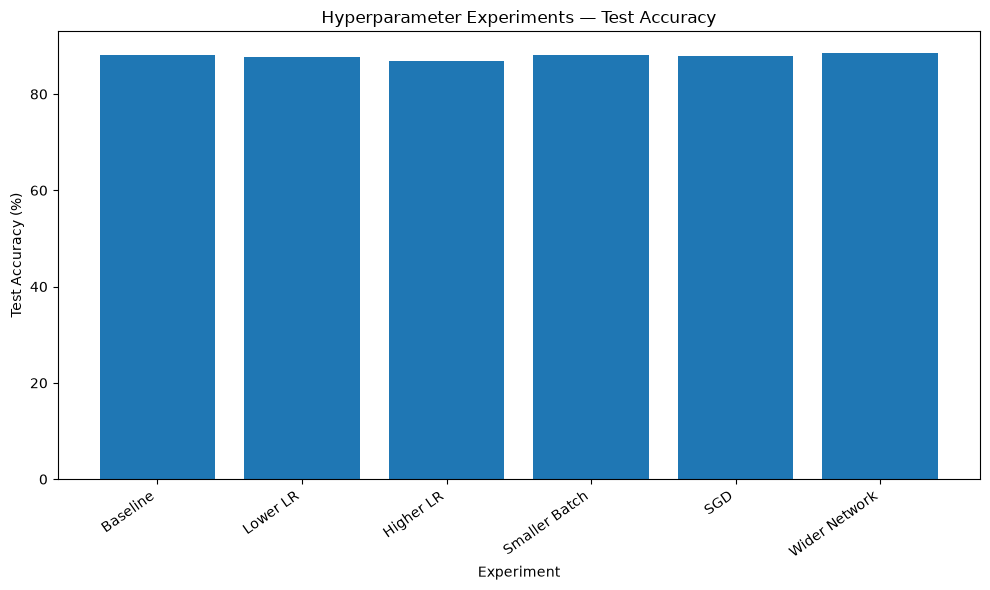

Saved: D:\GTVT-UTH\HK_He_2026\DEEP_LEARNING\UTH-Deep-Learning-nhom2\Practice_1\figures\hyperparameter_test_accuracy.png


In [49]:
ACCURACY_PATH = (
    FIGURE_DIR
    / "hyperparameter_test_accuracy.png"
)

names = [
    result["experiment"]
    for result in results
]

accuracies = [
    result["test_accuracy"]
    for result in results
]

plt.figure(figsize=(10, 6))
plt.bar(names, accuracies)
plt.title("Hyperparameter Experiments — Test Accuracy")
plt.xlabel("Experiment")
plt.ylabel("Test Accuracy (%)")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(
    ACCURACY_PATH,
    dpi=300,
    bbox_inches="tight",
)
plt.show()

print("Saved:", ACCURACY_PATH)


## 6.9 Test loss comparison 

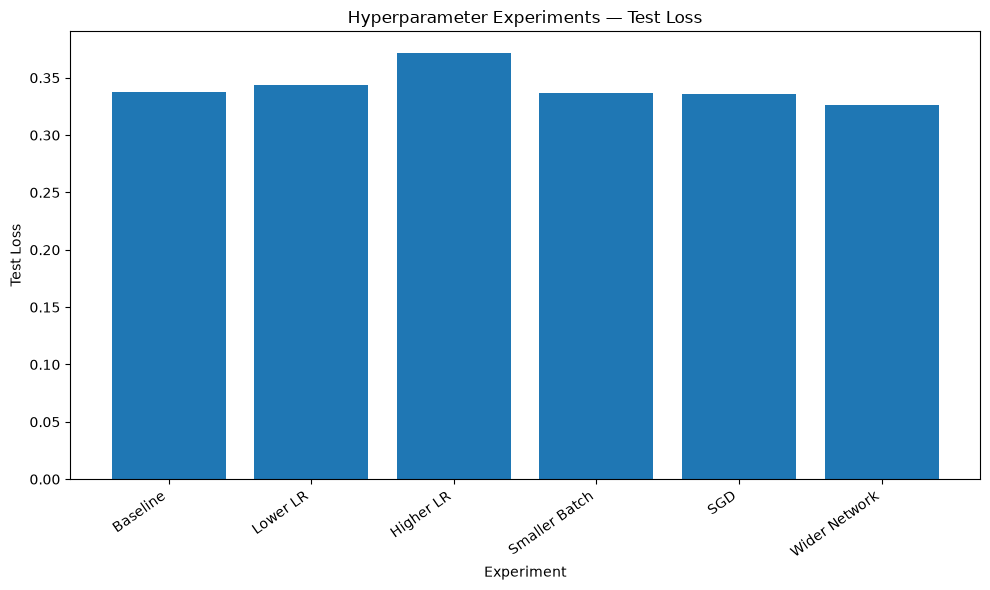

Saved: D:\GTVT-UTH\HK_He_2026\DEEP_LEARNING\UTH-Deep-Learning-nhom2\Practice_1\figures\hyperparameter_test_loss.png


In [50]:
TEST_LOSS_PATH = (
    FIGURE_DIR
    / "hyperparameter_test_loss.png"
)

losses = [
    result["test_loss"]
    for result in results
]

plt.figure(figsize=(10, 6))
plt.bar(names, losses)
plt.title("Hyperparameter Experiments — Test Loss")
plt.xlabel("Experiment")
plt.ylabel("Test Loss")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(
    TEST_LOSS_PATH,
    dpi=300,
    bbox_inches="tight",
)
plt.show()

print("Saved:", TEST_LOSS_PATH)


## 6.10. Training loss curves


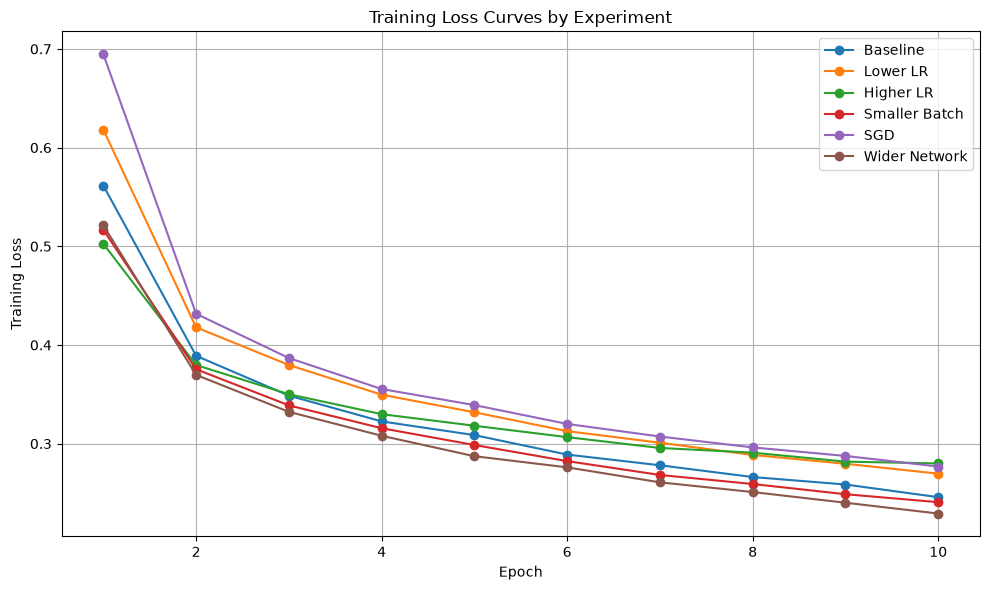

Saved: D:\GTVT-UTH\HK_He_2026\DEEP_LEARNING\UTH-Deep-Learning-nhom2\Practice_1\figures\hyperparameter_loss_curves.png


In [51]:
LOSS_CURVES_PATH = (
    FIGURE_DIR
    / "hyperparameter_loss_curves.png"
)

plt.figure(figsize=(10, 6))

for name, loss_history in histories.items():
    plt.plot(
        range(1, len(loss_history) + 1),
        loss_history,
        marker="o",
        label=name,
    )

plt.title("Training Loss Curves by Experiment")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(
    LOSS_CURVES_PATH,
    dpi=300,
    bbox_inches="tight",
)
plt.show()

print("Saved:", LOSS_CURVES_PATH)


## 6.11. Load and evaluate the official TV4 checkpoint

 
Checkpoint này sử dụng kiến trúc MLP:

`784 → 128 → 64 → 10`

 

In [52]:
from pathlib import Path
import hashlib
import torch


TV4_CHECKPOINT_PATH = (
    MODEL_DIR
    / "fashion_mnist_mlp_trained.pth"
)


if not TV4_CHECKPOINT_PATH.exists():
    raise FileNotFoundError(
        "Không tìm thấy checkpoint chính thức của TV4:\n"
        f"{TV4_CHECKPOINT_PATH}\n\n"
        "Hãy kiểm tra nhánh hiện tại là len-brand và file đã được "
        "commit vào Practice_1/models/."
    )


 
# Tính SHA256 để xác nhận đúng checkpoint
 
def calculate_sha256(file_path: Path) -> str:
    sha256 = hashlib.sha256()

    with file_path.open("rb") as file:
        for chunk in iter(
            lambda: file.read(1024 * 1024),
            b"",
        ):
            sha256.update(chunk)

    return sha256.hexdigest()


tv4_checkpoint_hash = calculate_sha256(
    TV4_CHECKPOINT_PATH
)


 
# Khởi tạo đúng kiến trúc model của TV3
 
tv4_model = NeuralNetwork().to(device)


 
# Load trọng số đã train của TV4
 
tv4_state_dict = torch.load(
    TV4_CHECKPOINT_PATH,
    map_location=device,
    weights_only=True,
)

tv4_model.load_state_dict(
    tv4_state_dict,
    strict=True,
)

tv4_model.eval()


 
# Đánh giá checkpoint TV4 bằng cùng test_loader
 
tv4_test_loss, tv4_test_accuracy = evaluate_model(
    model=tv4_model,
    test_loader=test_loader,
    device=device,
)


 

print("Checkpoint path :", TV4_CHECKPOINT_PATH.resolve())
print(
    "File size       :",
    TV4_CHECKPOINT_PATH.stat().st_size,
    "bytes",
)
print("SHA256          :", tv4_checkpoint_hash)
print(f"Test Loss       : {tv4_test_loss:.4f}")
print(f"Test Accuracy   : {tv4_test_accuracy:.2f}%")

Checkpoint path : D:\GTVT-UTH\HK_He_2026\DEEP_LEARNING\UTH-Deep-Learning-nhom2\Practice_1\models\fashion_mnist_mlp_trained.pth
File size       : 440941 bytes
SHA256          : e0e39d41061375d354f20365de4b6d35429b31d49cb4d6103eb2a71a03c98eee
Test Loss       : 0.3278
Test Accuracy   : 88.29%


In [53]:
print("TV4 CHECKPOINT VS TV6 BEST EXPERIMENT")
 

print(
    f"TV4 official checkpoint : "
    f"Loss = {tv4_test_loss:.4f}, "
    f"Accuracy = {tv4_test_accuracy:.2f}%"
)

print(
    f"TV6 best experiment     : "
    f"Accuracy = {best_accuracy:.2f}%"
)

accuracy_difference = (
    best_accuracy - tv4_test_accuracy
)

print(
    f"Accuracy difference     : "
    f"{accuracy_difference:+.2f}%"
)

if accuracy_difference > 0:
    print(
        "Kết luận: cấu hình tốt nhất của TV6 có "
        "accuracy cao hơn checkpoint TV4."
    )
elif accuracy_difference < 0:
    print(
        "Kết luận: checkpoint TV4 có accuracy "
        "cao hơn cấu hình tốt nhất của TV6."
    )
else:
    print(
        "Kết luận: hai kết quả có accuracy bằng nhau."
    )

TV4 CHECKPOINT VS TV6 BEST EXPERIMENT
TV4 official checkpoint : Loss = 0.3278, Accuracy = 88.29%
TV6 best experiment     : Accuracy = 88.60%
Accuracy difference     : +0.31%
Kết luận: cấu hình tốt nhất của TV6 có accuracy cao hơn checkpoint TV4.


In [54]:
best_result = max(
    results,
    key=lambda row: row["test_accuracy"],
)

print("BEST TV6 EXPERIMENT")
print("=" * 55)

print("Experiment       :", best_result["experiment"])
print("Batch size       :", best_result["batch_size"])
print("Learning rate    :", best_result["learning_rate"])
print("Optimizer        :", best_result["optimizer"])
print("Hidden layers    :", best_result["hidden_sizes"])
print("Epochs           :", best_result["epochs"])
print(f"Test Loss        : {best_result['test_loss']:.4f}")
print(f"Test Accuracy    : {best_result['test_accuracy']:.2f}%")
print(
    f"Training time    : "
    f"{best_result['training_time_seconds']:.2f}s"
)

BEST TV6 EXPERIMENT
Experiment       : Wider Network
Batch size       : 64
Learning rate    : 0.001
Optimizer        : Adam
Hidden layers    : 256-128
Epochs           : 10
Test Loss        : 0.3266
Test Accuracy    : 88.60%
Training time    : 91.61s


## 6.12. Result analysis

In [55]:
BEST_TV6_MODEL_PATH = (
    MODEL_DIR
    / "best_hyperparameter_model.pth"
)

torch.save(
    {
        "model_state_dict": best_state_dict,
        "config": best_config,
        "test_accuracy": best_accuracy,
        "seed": SEED,
        "epochs": EPOCHS,
    },
    BEST_TV6_MODEL_PATH,
)

 
print("Experiment    :", best_config["name"])
print("Batch size    :", best_config["batch_size"])
print("Learning rate :", best_config["learning_rate"])
print("Optimizer     :", best_config["optimizer"])
print("Hidden sizes  :", best_config["hidden_sizes"])
print(f"Test Accuracy : {best_accuracy:.2f}%")
print("Saved path    :", BEST_TV6_MODEL_PATH)

Experiment    : Wider Network
Batch size    : 64
Learning rate : 0.001
Optimizer     : Adam
Hidden sizes  : (256, 128)
Test Accuracy : 88.60%
Saved path    : D:\GTVT-UTH\HK_He_2026\DEEP_LEARNING\UTH-Deep-Learning-nhom2\Practice_1\models\best_hyperparameter_model.pth
